In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Original training data:", x_train.shape)
print("Original testing data:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1313s 8us/step
Original training data: (50000, 32, 32, 3)
Original testing data: (10000, 32, 32, 3)


In [4]:
# Use smaller dataset for faster training
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:2000]
y_test = y_test[:2000]

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (10000, 32, 32, 3)
Testing data: (2000, 32, 32, 3)


In [5]:
# Convert pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

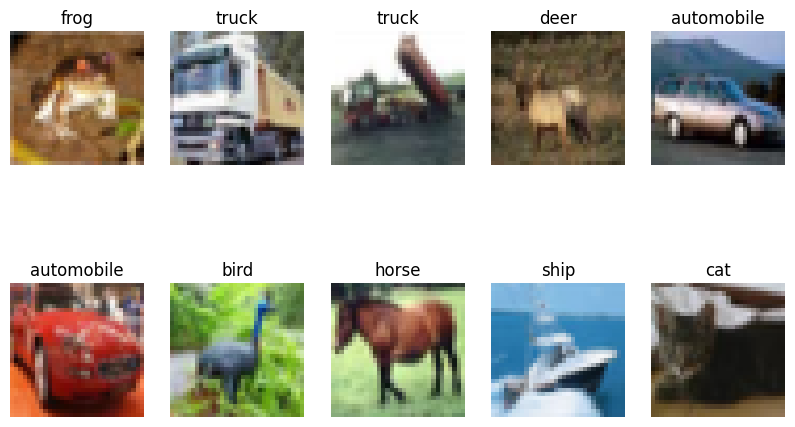

In [6]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [7]:
model = models.Sequential([

    # Convolution layer
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second convolution layer
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution layer
    layers.Conv2D(64, (3, 3), activation="relu"),

    # Convert feature maps into one dimension
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(64, activation="relu"),

    # Output layer - 10 classes
    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.2598 - loss: 1.9756 - val_accuracy: 0.3450 - val_loss: 1.7506
Epoch 2/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.3968 - loss: 1.6524 - val_accuracy: 0.4330 - val_loss: 1.5191
Epoch 3/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.4706 - loss: 1.4649 - val_accuracy: 0.4590 - val_loss: 1.4468
Epoch 4/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.5146 - loss: 1.3522 - val_accuracy: 0.5030 - val_loss: 1.3206
Epoch 5/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.5457 - loss: 1.2760 - val_accuracy: 0.5300 - val_loss: 1.2954


In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

63/63 - 1s - 13ms/step - accuracy: 0.5325 - loss: 1.3085
Test Accuracy: 0.5325000286102295
Test Loss: 1.308529257774353


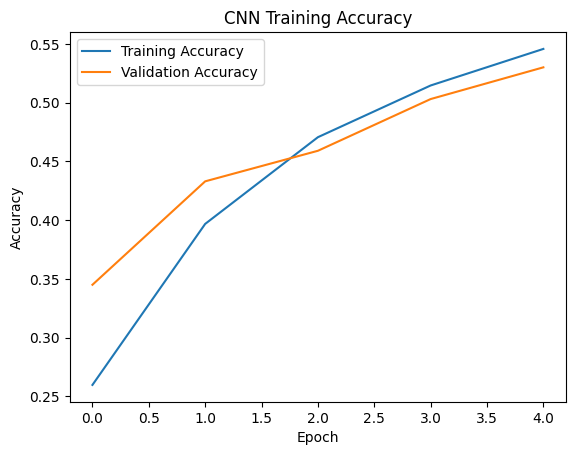

In [11]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training Accuracy")

plt.legend()
plt.show()

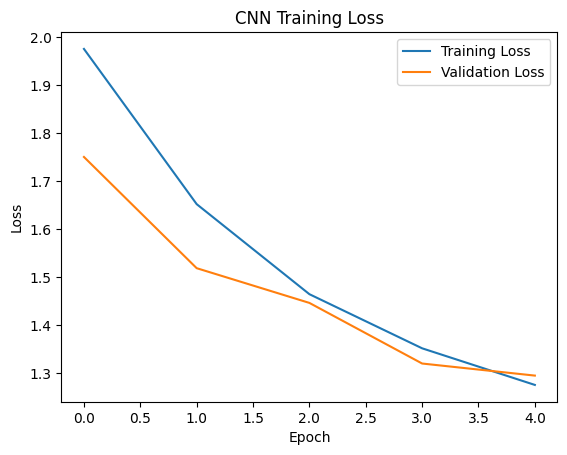

In [12]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")

plt.legend()
plt.show()

In [13]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", class_names[predicted_labels[0]])
print("Actual:", class_names[y_test[0][0]])

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
Predicted: cat
Actual: cat


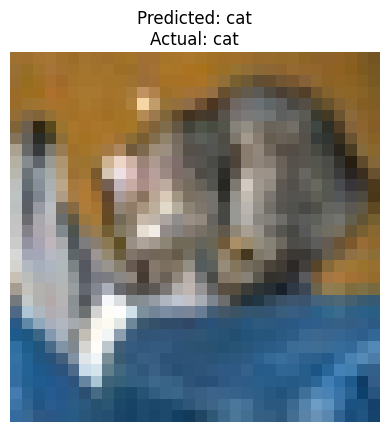

In [14]:
plt.imshow(x_test[0])
plt.title(
    "Predicted: " + class_names[predicted_labels[0]] +
    "\nActual: " + class_names[y_test[0][0]]
)
plt.axis("off")
plt.show()

In [15]:
model.save("cifar10_cnn_model.keras")

print("Model saved successfully!")

Model saved successfully!
